# BulkFluoRDF Condition Comparison

This notebook loads and compares the aggregated Radial Distribution Function (RDF) curves across four experimental conditions:
1. **undiff** (Undifferentiated SPEN Control)
2. **Aux1h** (Auxin 1h treatment)
3. **Aux24h** (Auxin 24h treatment)
4. **Dox24h** (Dox 24h treatment)

The curves for both H3K27ac and SPEN signals are plotted together on the same axes for comparison.

In [1]:
import os
import importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Define paths and ensure output directory exists
base_dir = Path('/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-SACD')
out_dir = base_dir
out_dir.mkdir(parents=True, exist_ok=True)

# Configure matplotlib cache directory locally
(out_dir / '.cache' / 'matplotlib').mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(out_dir / '.cache' / 'matplotlib')

# Import BulkFluoRDF library
import BulkFluoRDF as rdf
rdf = importlib.reload(rdf)

# Style configuration for publication-quality plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 8

In [2]:
# Configure colors and files for each condition
conditions = {
    'undiff': {
        'name': 'undiff (Control)',
        'color': '#00274c',  # Navy
        'file': base_dir / 'aggregated_rdf_summary-undiff.csv'
    },
    # 'Aux1h': {
    #     'name': 'Auxin 1h',
    #     'color': '#2ca02c',  # Green
    #     'file': base_dir / 'aggregated_rdf_summary-Aux1h.csv'
    # },
    # 'Aux24h': {
    #     'name': 'Auxin 24h',
    #     'color': '#ff7f0e',  # Orange
    #     'file': base_dir / 'aggregated_rdf_summary-Aux24h.csv'
    # },
    'Dox24h': {
        'name': 'Dox 24h',
        'color': '#d62728',  # Red
        'file': base_dir / 'aggregated_rdf_summary-Dox24h.csv'
    }
}

dfs = {}
for cond, info in conditions.items():
    if info['file'].exists():
        dfs[cond] = pd.read_csv(info['file'])
    else:
        # Fallback to condition subdirectory search
        alt_path = base_dir / cond / f'aggregated_rdf_summary-{cond}.csv'
        if alt_path.exists():
            dfs[cond] = pd.read_csv(alt_path)
        else:
            raise FileNotFoundError(f"Aggregated summary CSV for {cond} not found at {info['file']} or {alt_path}")

    print(f"Loaded {cond}: {dfs[cond].shape[0]} bins, max hubs = {dfs[cond]['n_hubs'].max()}")

Loaded undiff: 19 bins, max hubs = 3093
Loaded Dox24h: 19 bins, max hubs = 4960


Saved comparison figure to: /Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/processed-SACD/aggregated_rdf_comparison.png


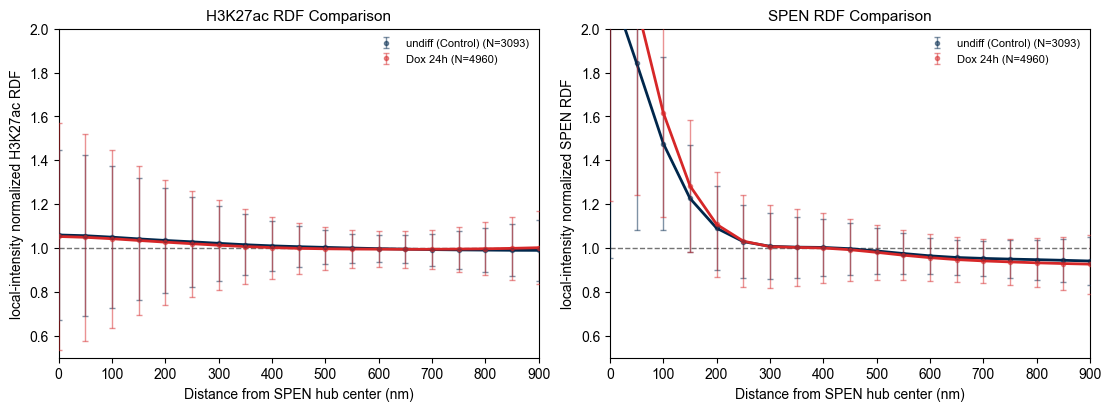

In [3]:
# Create the comparison figure
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True, sharex=True)

# Define plotting specifications: (axes, value_prefix, channel_name, y_axis_label, plot_title)
plot_specs = [
    (axes[0], 'h3k27ac_rdf', 'H3K27ac', 'local-intensity normalized H3K27ac RDF', 'H3K27ac RDF Comparison'),
    (axes[1], 'spen_rdf', 'SPEN', 'local-intensity normalized SPEN RDF', 'SPEN RDF Comparison')
]

for ax, prefix, channel, ylabel, title in plot_specs:
    for cond, info in conditions.items():
        df = dfs[cond]
        x = df['radius_start_nm'].to_numpy(float)
        mean = df[f'{prefix}_mean'].to_numpy(float)
        std = df[f'{prefix}_std'].to_numpy(float)
        n_hubs = int(df['n_hubs'].max())

        # Plot using standard pipeline style
        rdf.plot_rdf_mean_with_std(
            ax,
            x,
            mean,
            std,
            color=info['color'],
            label=f"{info['name']} (N={n_hubs})",
            zorder=4
        )

    ax.axhline(1.0, color="0.45", lw=1, ls="--")
    ax.set_xlim(float(df['radius_start_nm'].min()), float(df['radius_start_nm'].max()))
    ax.set_xlabel("Distance from SPEN hub center (nm)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    rdf.clamp_rdf_ylim(ax)
    ax.legend(frameon=False, fontsize=8, loc="best")

# Save comparison figure
fig_path = out_dir / 'aggregated_rdf_comparison.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison figure to: {fig_path}")
plt.show()